## CASE STUDY: 
## DATA EXPLORATORY ANALYSIS AND HYPOTHESIS 
## TESTING FOR  INSURANCE CLAIMS DATA 

## Q1. Preparing Dataset

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

claim=pd.read_csv(f"M:/DISK M/Python~SS/Pandas Casestudy/Ps-softech Insurance Claims Case Study 3/claims.csv")
print(claim['customer_id'].nunique())
claim

1093


,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No
...,...,...,...,...,...,...,...,...,...,...
1095,97727122,35951012,Other driver error,06/11/2017,Auto,No,Material only,$3059,4.0,Yes
1096,10247193,14818669,Natural causes,03/14/2018,Auto,No,Material only,$1520,2.0,No
1097,79807493,85322831,Other driver error,02/09/2018,Auto,No,Material and injury,$23575,2.0,Yes
1098,69299345,73449366,Other causes,03/21/2018,Auto,Unknown,Material and injury,$25120,1.0,No


In [56]:
import pandas as pd

cust=pd.read_csv("M:/DISK M/Python~SS/Pandas Casestudy/Ps-softech Insurance Claims Case Study 3/cust_demographics.csv")
print(cust['CUST_ID'].nunique())
cust

1085


,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver
3,47830476,Female,01-May-86,MA,413-187-7945,Silver
4,19269962,Male,13-May-77,NV,956-871-8691,Gold
...,...,...,...,...,...,...
1080,79539873,Female,15-Mar-81,ND,459-425-4319,Platinum
1081,42364152,Female,07-Jul-96,ID,529-462-1635,Silver
1082,19888166,Male,11-Apr-90,WI,712-651-9613,Gold
1083,11256802,Female,22-Oct-64,LA,469-345-5617,Silver


Merging claim and cust datasets

In [57]:
claim_cust=pd.merge(claim,cust,how="left",left_on='customer_id',right_on='CUST_ID')
claim_cust

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No,21868593.0,Female,12-Jan-79,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No,75740424.0,Female,13-Jan-70,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes,30308357.0,Female,11-Mar-84,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No,47830476.0,Female,01-May-86,MA,413-187-7945,Silver
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No,19269962.0,Male,13-May-77,NV,956-871-8691,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,97727122,35951012,Other driver error,06/11/2017,Auto,No,Material only,$3059,4.0,Yes,NaN,NaN,NaN,NaN,NaN,NaN
1096,10247193,14818669,Natural causes,03/14/2018,Auto,No,Material only,$1520,2.0,No,NaN,NaN,NaN,NaN,NaN,NaN
1097,79807493,85322831,Other driver error,02/09/2018,Auto,No,Material and injury,$23575,2.0,Yes,NaN,NaN,NaN,NaN,NaN,NaN
1098,69299345,73449366,Other causes,03/21/2018,Auto,Unknown,Material and injury,$25120,1.0,No,NaN,NaN,NaN,NaN,NaN,NaN


## Q2. Perform a data audit for the datatypes

In [58]:
claim_cust.dtypes

claim_id                 int64
customer_id              int64
incident_cause             str
claim_date                 str
claim_area                 str
police_report              str
claim_type                 str
claim_amount               str
total_policy_claims    float64
fraudulent                 str
CUST_ID                float64
gender                     str
DateOfBirth                str
State                      str
Contact                    str
Segment                    str
dtype: object

In [59]:
claim_cust['DateOfBirth']=pd.to_datetime(claim_cust['DateOfBirth'], format='%d-%b-%y')
claim_cust

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No,21868593.0,Female,1979-01-12,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No,75740424.0,Female,1970-01-13,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes,30308357.0,Female,1984-03-11,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No,47830476.0,Female,1986-05-01,MA,413-187-7945,Silver
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No,19269962.0,Male,1977-05-13,NV,956-871-8691,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,97727122,35951012,Other driver error,06/11/2017,Auto,No,Material only,$3059,4.0,Yes,NaN,NaN,NaT,NaN,NaN,NaN
1096,10247193,14818669,Natural causes,03/14/2018,Auto,No,Material only,$1520,2.0,No,NaN,NaN,NaT,NaN,NaN,NaN
1097,79807493,85322831,Other driver error,02/09/2018,Auto,No,Material and injury,$23575,2.0,Yes,NaN,NaN,NaT,NaN,NaN,NaN
1098,69299345,73449366,Other causes,03/21/2018,Auto,Unknown,Material and injury,$25120,1.0,No,NaN,NaN,NaT,NaN,NaN,NaN


In [60]:
claim_cust['claim_date']=pd.to_datetime(claim_cust['claim_date'],dayfirst=True,format='mixed')
claim_cust

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,2017-11-27,Auto,No,Material only,$2980,1.0,No,21868593.0,Female,1979-01-12,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,2018-03-10,Home,Unknown,Material only,$2980,3.0,No,75740424.0,Female,1970-01-13,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,2018-02-02,Auto,No,Material only,$3369.5,1.0,Yes,30308357.0,Female,1984-03-11,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,2018-06-17,Auto,No,Material only,$1680,1.0,No,47830476.0,Female,1986-05-01,MA,413-187-7945,Silver
4,22890252,19269962,Crime,2018-01-13,Auto,No,Material only,$2680,1.0,No,19269962.0,Male,1977-05-13,NV,956-871-8691,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,97727122,35951012,Other driver error,2017-11-06,Auto,No,Material only,$3059,4.0,Yes,NaN,NaN,NaT,NaN,NaN,NaN
1096,10247193,14818669,Natural causes,2018-03-14,Auto,No,Material only,$1520,2.0,No,NaN,NaN,NaT,NaN,NaN,NaN
1097,79807493,85322831,Other driver error,2018-09-02,Auto,No,Material and injury,$23575,2.0,Yes,NaN,NaN,NaT,NaN,NaN,NaN
1098,69299345,73449366,Other causes,2018-03-21,Auto,Unknown,Material and injury,$25120,1.0,No,NaN,NaN,NaT,NaN,NaN,NaN


## Q3. 
Convert the column claim_amount to numeric. Use the appropriate 
modules/attributes to remove the $ sign. 

In [61]:
claim_cust['claim_amount']=claim_cust['claim_amount'].str.replace('$', '', regex=False).astype(float)
claim_cust

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,2017-11-27,Auto,No,Material only,2980.0,1.0,No,21868593.0,Female,1979-01-12,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,2018-03-10,Home,Unknown,Material only,2980.0,3.0,No,75740424.0,Female,1970-01-13,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,2018-02-02,Auto,No,Material only,3369.5,1.0,Yes,30308357.0,Female,1984-03-11,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,2018-06-17,Auto,No,Material only,1680.0,1.0,No,47830476.0,Female,1986-05-01,MA,413-187-7945,Silver
4,22890252,19269962,Crime,2018-01-13,Auto,No,Material only,2680.0,1.0,No,19269962.0,Male,1977-05-13,NV,956-871-8691,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,97727122,35951012,Other driver error,2017-11-06,Auto,No,Material only,3059.0,4.0,Yes,NaN,NaN,NaT,NaN,NaN,NaN
1096,10247193,14818669,Natural causes,2018-03-14,Auto,No,Material only,1520.0,2.0,No,NaN,NaN,NaT,NaN,NaN,NaN
1097,79807493,85322831,Other driver error,2018-09-02,Auto,No,Material and injury,23575.0,2.0,Yes,NaN,NaN,NaT,NaN,NaN,NaN
1098,69299345,73449366,Other causes,2018-03-21,Auto,Unknown,Material and injury,25120.0,1.0,No,NaN,NaN,NaT,NaN,NaN,NaN


## Q4. 
Create an alert flag (1, 0) for all injury claims that were not reported to the police.

In [62]:
claim_cust['claim_type'].value_counts()

claim_type
Material only          663
Material and injury    241
Injury only            196
Name: count, dtype: int64

In [63]:
claim_cust['Alert_flag']=0
claim_cust.loc[(claim_cust['claim_type'].isin(['Material and injury', 'Injury only'])) & (claim_cust['police_report'] == 'No'), 'Alert_flag'] = 1

claim_cust


,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment,Alert_flag
0,54004764,21868593,Driver error,2017-11-27,Auto,No,Material only,2980.0,1.0,No,21868593.0,Female,1979-01-12,VT,789-916-8172,Platinum,0
1,33985796,75740424,Crime,2018-03-10,Home,Unknown,Material only,2980.0,3.0,No,75740424.0,Female,1970-01-13,ME,265-543-1264,Silver,0
2,53522022,30308357,Other driver error,2018-02-02,Auto,No,Material only,3369.5,1.0,Yes,30308357.0,Female,1984-03-11,TN,798-631-4758,Silver,0
3,13015401,47830476,Natural causes,2018-06-17,Auto,No,Material only,1680.0,1.0,No,47830476.0,Female,1986-05-01,MA,413-187-7945,Silver,0
4,22890252,19269962,Crime,2018-01-13,Auto,No,Material only,2680.0,1.0,No,19269962.0,Male,1977-05-13,NV,956-871-8691,Gold,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,97727122,35951012,Other driver error,2017-11-06,Auto,No,Material only,3059.0,4.0,Yes,NaN,NaN,NaT,NaN,NaN,NaN,0
1096,10247193,14818669,Natural causes,2018-03-14,Auto,No,Material only,1520.0,2.0,No,NaN,NaN,NaT,NaN,NaN,NaN,0
1097,79807493,85322831,Other driver error,2018-09-02,Auto,No,Material and injury,23575.0,2.0,Yes,NaN,NaN,NaT,NaN,NaN,NaN,1
1098,69299345,73449366,Other causes,2018-03-21,Auto,Unknown,Material and injury,25120.0,1.0,No,NaN,NaN,NaT,NaN,NaN,NaN,0


## Q5. 
Each customer may have multiple insurance claims, but the final dataset should contain only one record per customer and retain the most recent observation for each customer_id, removing all older duplicate records.

In [64]:
claim_cust = claim_cust.sort_values('claim_date', ascending=False).drop_duplicates('customer_id')
claim_cust

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment,Alert_flag
786,98596005,73876237,Driver error,2018-12-09,Auto,No,Material only,2130.0,1.0,No,73876237.0,Female,1975-01-27,AL,879-185-4857,Silver,0
975,66301062,30015627,Natural causes,2018-12-09,Auto,Yes,Material only,2208.0,4.0,Yes,30015627.0,Male,1969-09-11,SC,254-523-1634,Silver,0
130,4112041,58402401,Other causes,2018-12-09,Auto,Unknown,Material and injury,32710.0,1.0,No,58402401.0,Male,1979-06-13,KS,134-129-8167,Silver,0
898,4812972,78341228,Natural causes,2018-12-09,Auto,Unknown,Material only,2090.0,1.0,No,78341228.0,Male,1986-11-26,SD,475-573-2957,Gold,0
301,2581621,18213216,Other causes,2018-12-09,Auto,Unknown,Material and injury,21942.0,2.0,Yes,18213216.0,Male,1969-10-06,KY,416-461-9145,Silver,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,70512964,22756942,Driver error,2017-01-01,Auto,Yes,Injury only,20310.0,1.0,No,22756942.0,Male,1982-10-09,FL,462-823-3126,Silver,0
1064,56358443,75934330,Natural causes,2017-01-01,Auto,Yes,Injury only,20630.0,1.0,No,75934330.0,Female,1987-10-09,ME,951-941-3975,Platinum,0
116,39131766,39587790,Other causes,2017-01-01,Auto,No,Material only,2967.0,1.0,Yes,39587790.0,Male,2065-01-10,LA,615-154-3516,Gold,0
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.0,3.0,No,65176092.0,Male,1975-11-23,NC,651-379-2486,Silver,1


## Q6. 
Check for missing values and impute the missing values with an 
appropriate value. (mean for continuous and mode for categorical) 

In [65]:
missing=claim_cust.isnull().sum()
missing

claim_id                0
customer_id             0
incident_cause          0
claim_date              0
claim_area              0
police_report           0
claim_type              0
claim_amount           65
total_policy_claims    10
fraudulent              0
CUST_ID                15
gender                 15
DateOfBirth            15
State                  15
Contact                15
Segment                15
Alert_flag              0
dtype: int64

Mean for continuous 

In [66]:
# claim_amount
mean=claim_cust['claim_amount'].mean()
print(f"Mean of claim amount : {mean}")
claim_cust['claim_amount']=claim_cust['claim_amount'].fillna(mean)

# total_policy_claims
mean=claim_cust['total_policy_claims'].mean()
print(f"Mean of total policy claims : {mean}")
claim_cust['total_policy_claims']=claim_cust['total_policy_claims'].fillna(mean)

Mean of claim amount : 12475.499513618677
Mean of total policy claims : 1.5937211449676825


Mode for categorical

In [67]:
# Categorical Columns
categorical_cols = ['DateOfBirth','gender','State', 'Contact', 'Segment']

for col in categorical_cols:
    mode=claim_cust[col].mode()
    print(f"Mode of {col} : {mode[0]}")
    claim_cust[col]=claim_cust[col].fillna(mode[0])

# CUST_ID is an ID column, so don't impute it
claim_cust = claim_cust.drop(columns=['CUST_ID'])

# Final check
missing=claim_cust.isnull().sum()
missing

Mode of DateOfBirth : 1969-01-01 00:00:00
Mode of gender : Male
Mode of State : NY
Mode of Contact : 123-346-2854
Mode of Segment : Gold


claim_id               0
customer_id            0
incident_cause         0
claim_date             0
claim_area             0
police_report          0
claim_type             0
claim_amount           0
total_policy_claims    0
fraudulent             0
gender                 0
DateOfBirth            0
State                  0
Contact                0
Segment                0
Alert_flag             0
dtype: int64

## Q7.
7. Calculate the age of customers in years. Based on the age, categorize 
the customers according to the below criteria 
Children     < 18 
Youth        18-30 
Adult        30-60 
Senior       > 60 

In [68]:
import numpy as np
# 1. Calculate age
claim_cust['Age']=pd.Timestamp.now().year- claim_cust['DateOfBirth'].dt.year              # find age 

# 2. Invalid/future DOB se aayi negative ages ko missing karo
claim_cust.loc[claim_cust['Age'] < 0, 'Age'] = np.nan

claim_cust

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age
786,98596005,73876237,Driver error,2018-12-09,Auto,No,Material only,2130.0,1.0,No,Female,1975-01-27,AL,879-185-4857,Silver,0,51.0
975,66301062,30015627,Natural causes,2018-12-09,Auto,Yes,Material only,2208.0,4.0,Yes,Male,1969-09-11,SC,254-523-1634,Silver,0,57.0
130,4112041,58402401,Other causes,2018-12-09,Auto,Unknown,Material and injury,32710.0,1.0,No,Male,1979-06-13,KS,134-129-8167,Silver,0,47.0
898,4812972,78341228,Natural causes,2018-12-09,Auto,Unknown,Material only,2090.0,1.0,No,Male,1986-11-26,SD,475-573-2957,Gold,0,40.0
301,2581621,18213216,Other causes,2018-12-09,Auto,Unknown,Material and injury,21942.0,2.0,Yes,Male,1969-10-06,KY,416-461-9145,Silver,0,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,70512964,22756942,Driver error,2017-01-01,Auto,Yes,Injury only,20310.0,1.0,No,Male,1982-10-09,FL,462-823-3126,Silver,0,44.0
1064,56358443,75934330,Natural causes,2017-01-01,Auto,Yes,Injury only,20630.0,1.0,No,Female,1987-10-09,ME,951-941-3975,Platinum,0,39.0
116,39131766,39587790,Other causes,2017-01-01,Auto,No,Material only,2967.0,1.0,Yes,Male,2065-01-10,LA,615-154-3516,Gold,0,NaN
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.0,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,1,51.0


In [69]:
claim_cust['Age_Group'] = ''
claim_cust.loc[claim_cust['Age'] < 18, 'Age_Group'] = 'Children'
claim_cust.loc[(claim_cust['Age'] >= 18) & (claim_cust['Age'] <= 30),'Age_Group'] = 'Youth'
claim_cust.loc[(claim_cust['Age'] >= 31) & (claim_cust['Age'] <= 60),'Age_Group'] = 'Adult'
claim_cust.loc[claim_cust['Age'] > 60,'Age_Group'] = 'Senior'
claim_cust.loc[claim_cust['Age'].isna(), 'Age_Group'] = 'Unknown'

claim_cust

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age,Age_Group
786,98596005,73876237,Driver error,2018-12-09,Auto,No,Material only,2130.0,1.0,No,Female,1975-01-27,AL,879-185-4857,Silver,0,51.0,Adult
975,66301062,30015627,Natural causes,2018-12-09,Auto,Yes,Material only,2208.0,4.0,Yes,Male,1969-09-11,SC,254-523-1634,Silver,0,57.0,Adult
130,4112041,58402401,Other causes,2018-12-09,Auto,Unknown,Material and injury,32710.0,1.0,No,Male,1979-06-13,KS,134-129-8167,Silver,0,47.0,Adult
898,4812972,78341228,Natural causes,2018-12-09,Auto,Unknown,Material only,2090.0,1.0,No,Male,1986-11-26,SD,475-573-2957,Gold,0,40.0,Adult
301,2581621,18213216,Other causes,2018-12-09,Auto,Unknown,Material and injury,21942.0,2.0,Yes,Male,1969-10-06,KY,416-461-9145,Silver,0,57.0,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,70512964,22756942,Driver error,2017-01-01,Auto,Yes,Injury only,20310.0,1.0,No,Male,1982-10-09,FL,462-823-3126,Silver,0,44.0,Adult
1064,56358443,75934330,Natural causes,2017-01-01,Auto,Yes,Injury only,20630.0,1.0,No,Female,1987-10-09,ME,951-941-3975,Platinum,0,39.0,Adult
116,39131766,39587790,Other causes,2017-01-01,Auto,No,Material only,2967.0,1.0,Yes,Male,2065-01-10,LA,615-154-3516,Gold,0,NaN,Unknown
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.0,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,1,51.0,Adult


## Q8.
What is the average amount claimed by the customers from various 
segments? 

In [70]:
avg_claim = claim_cust.groupby('Segment')['claim_amount'].mean()
avg_claim

Segment
Gold        12761.663185
Platinum    12370.565077
Silver      12265.736955
Name: claim_amount, dtype: float64

## Q9.
What is the total claim amount based on incident cause for all the 
claims that have been done at least 20 days prior to 1st of October, 
2018. 

In [71]:
cutoff_date = pd.Timestamp('2018-10-01') - pd.Timedelta(days=20)
result = (
    claim_cust[claim_cust['claim_date'] <= cutoff_date]
    .groupby('incident_cause')['claim_amount']
    .sum()
)
result

incident_cause
Crime                 6.610095e+05
Driver error          3.438886e+06
Natural causes        1.284771e+06
Other causes          3.727116e+06
Other driver error    3.373908e+06
Name: claim_amount, dtype: float64

## Q10. 
How many adults from TX, DE and AK claimed insurance for driver 
related issues and causes?  

In [72]:
result = claim_cust[
    (claim_cust['Age_Group'] == 'Adult') &
    (claim_cust['State'].isin(['TX', 'DE', 'AK'])) &
    (claim_cust['incident_cause'].isin(['Driver error', 'Other driver error']))
]
print("Number of adults:", result['customer_id'].count())

Number of adults: 25


## Q11.
Draw a pie chart between the aggregated value of claim amount based 
on gender and segment. Represent the claim amount as a percentage 
on the pie chart. 

In [73]:
agg_value = claim_cust.groupby(['gender','Segment'])['claim_amount'].sum()
agg_value

gender  Segment 
Female  Gold        2.109808e+06
        Platinum    2.369538e+06
        Silver      1.897204e+06
Male    Gold        2.816193e+06
        Platinum    2.096235e+06
        Silver      2.346741e+06
Name: claim_amount, dtype: float64

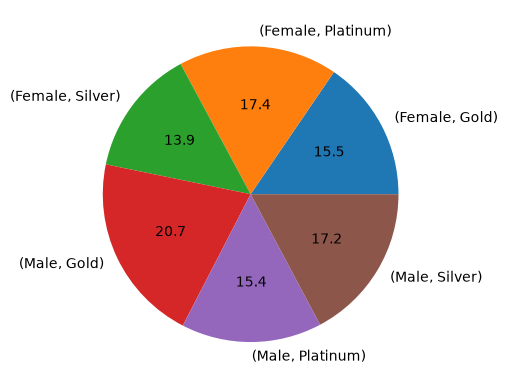

In [74]:
import matplotlib.pyplot as plt
agg_value.plot(kind="pie",autopct='%1.1f')
plt.show()

## Q12.
Among males and females, which gender had claimed the most for any 
type of driver related issues? E.g. This metric can be compared using a 
bar chart

In [75]:
claim_cust['incident_cause'].value_counts()

incident_cause
Other causes          289
Driver error          260
Other driver error    247
Natural causes        188
Crime                 109
Name: count, dtype: int64

In [76]:
data=claim_cust.loc[claim_cust['incident_cause'].isin(['Driver error','Other driver error'])].groupby('gender')['claim_amount'].sum()
data

gender
Female    3.136377e+06
Male      4.069583e+06
Name: claim_amount, dtype: float64

Bar graph

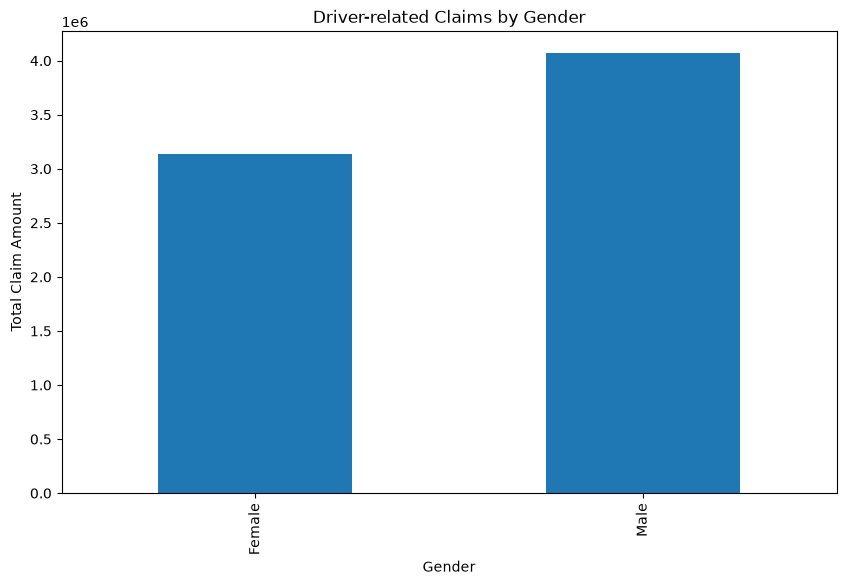

In [77]:
data.plot(kind='bar', figsize=(10, 6))

plt.title('Driver-related Claims by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Claim Amount')
plt.show()

## Q13.
Which age group had the maximum fraudulent policy claims? Visualize 
it on a bar chart. 

In [78]:
fraud_agegrp = (claim_cust[claim_cust['fraudulent'] == 'Yes'].groupby('Age_Group').size())
print(fraud_agegrp)

Age_Group
Adult      172
Unknown     60
Youth       20
dtype: int64


Bar graph

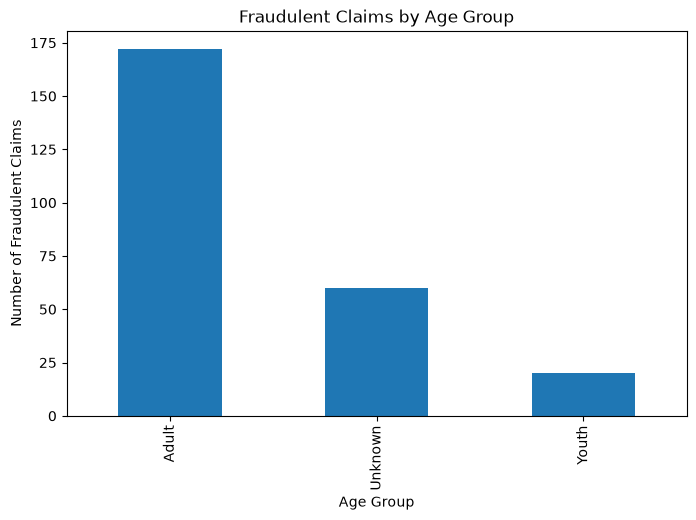

In [79]:
import matplotlib.pyplot as plt

fraud_agegrp.plot(kind='bar', figsize=(8, 5))

plt.title('Fraudulent Claims by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Fraudulent Claims')
plt.show()

## Q14.
Visualize the monthly trend of the total amount that has been claimed 
by the customers. Ensure that on the “month” axis, the month is in a 
chronological order not alphabetical order.  

In [80]:
claim_cust['Month'] = claim_cust['claim_date'].dt.month_name()
monthly_claim = claim_cust.groupby('Month')['claim_amount'].sum()

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_claim = monthly_claim.reindex(month_order)
monthly_claim

Month
January      1.375342e+06
February     9.838220e+05
March        1.422497e+06
April        1.067835e+06
May          9.678690e+05
June         1.417371e+06
July         1.521631e+06
August       7.969780e+05
September    1.122914e+06
October      1.580206e+06
November     6.699735e+05
December     7.092795e+05
Name: claim_amount, dtype: float64

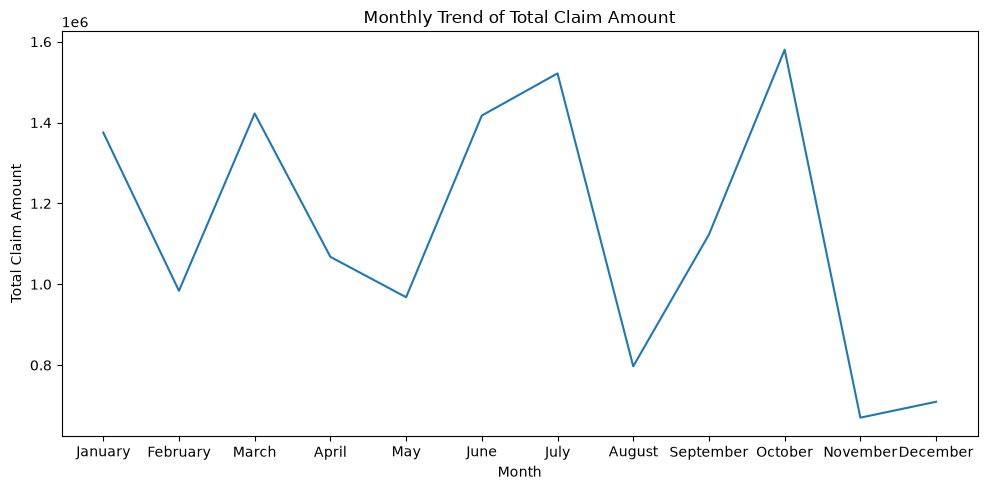

In [81]:
import matplotlib.pyplot as plt

monthly_claim.plot(kind='line',figsize=(10, 5))

plt.title('Monthly Trend of Total Claim Amount')
plt.xlabel('Month')
plt.ylabel('Total Claim Amount')
plt.xticks(range(12), month_order)
plt.tight_layout()
plt.show()

## Q15.
What is the average claim amount for gender and age categories and 
suitably represent the above using a facetted bar chart, one facet that 
represents fraudulent claims and the other for non-fraudulent claims. 

Based on the conclusions from exploratory analysis as well as suitable 
statistical tests, answer the below questions. Please include a detailed 
write-up on the parameters taken into consideration, the Hypothesis 
testing steps, conclusion from the p-values and the business implications of 
the statements.  

In [82]:
claim_cust.columns

Index(['claim_id', 'customer_id', 'incident_cause', 'claim_date', 'claim_area',
       'police_report', 'claim_type', 'claim_amount', 'total_policy_claims',
       'fraudulent', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment',
       'Alert_flag', 'Age', 'Age_Group', 'Month'],
      dtype='str')

In [83]:
avg_claim = claim_cust.groupby(['gender','Age_Group','fraudulent'])['claim_amount'].mean() .reset_index()
avg_claim

,gender,Age_Group,fraudulent,claim_amount
0,Female,Adult,No,12627.784372
1,Female,Adult,Yes,13809.525261
2,Female,Unknown,No,12305.107905
3,Female,Unknown,Yes,6440.328571
4,Female,Youth,No,11222.022201
5,Female,Youth,Yes,6861.136319
6,Male,Adult,No,12322.331598
7,Male,Adult,Yes,14320.956958
8,Male,Unknown,No,11600.582459
9,Male,Unknown,Yes,16923.860000


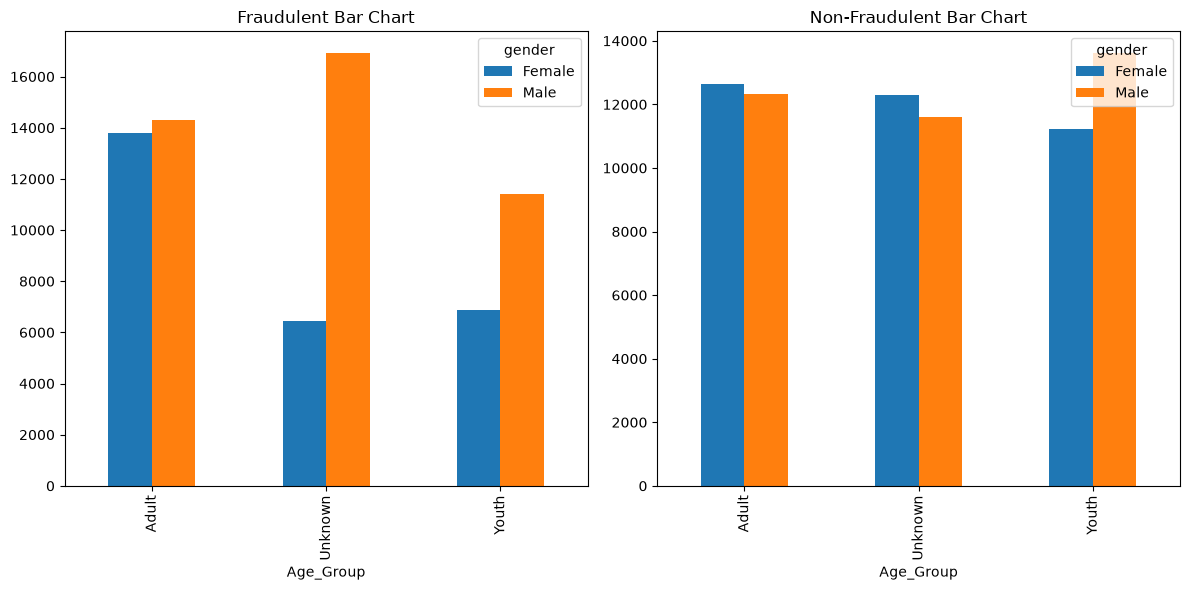

In [84]:
fraud = avg_claim[avg_claim['fraudulent'] == 'Yes'].pivot(index='Age_Group', columns='gender', values='claim_amount')
non_fraud = avg_claim[avg_claim['fraudulent'] == 'No'].pivot(index='Age_Group', columns='gender', values='claim_amount')

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
fraud.plot(
    kind='bar',
    ax=plt.gca()                         # ax=plt.gca() means Get Current Axes
)
plt.title('Fraudulent Bar Chart')


plt.subplot(1,2,2)
non_fraud.plot(
    kind='bar',
    ax=plt.gca()
)
plt.title('Non-Fraudulent Bar Chart')

plt.tight_layout()
plt.show()

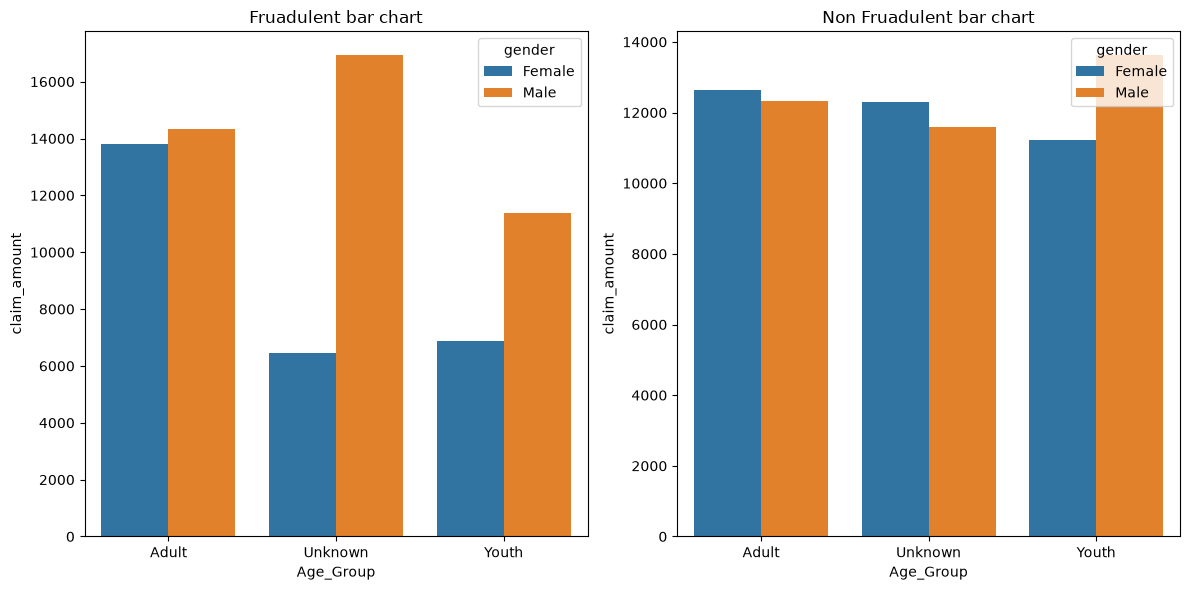

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.barplot(
    data=avg_claim[avg_claim['fraudulent'] == 'Yes'],
    x='Age_Group',
    y='claim_amount',
    hue='gender'
)
plt.title('Fruadulent bar chart')

plt.subplot(1,2,2)
sns.barplot(
    data=avg_claim[avg_claim['fraudulent'] == 'No'],
    x='Age_Group',
    y='claim_amount',
    hue='gender'

)
plt.title('Non Fruadulent bar chart')

plt.tight_layout()
plt.show()

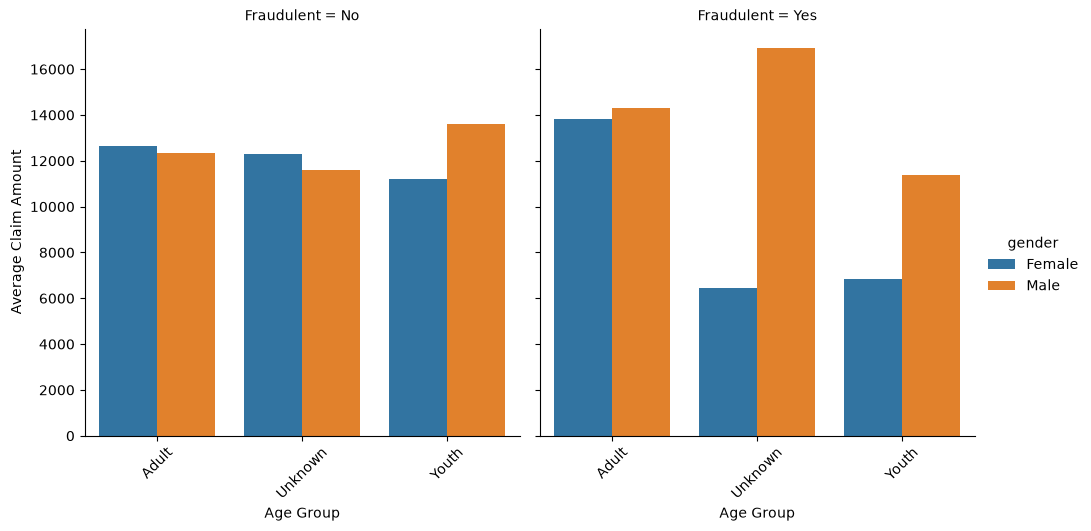

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=avg_claim,
    x='Age_Group',
    y='claim_amount',
    hue='gender',
    col='fraudulent',
    kind='bar',
)

g.set_axis_labels('Age Group', 'Average Claim Amount')
g.set_titles('Fraudulent = {col_name}')
g.set_xticklabels(rotation=45)
plt.show()

## Q16. 
Is there any similarity in the amount claimed by males and females? 

In [87]:
from scipy.stats import ttest_ind

male = claim_cust.loc[
    claim_cust['gender'] == 'Male',
    'claim_amount'
].dropna()

female = claim_cust.loc[
    claim_cust['gender'] == 'Female',
    'claim_amount'
].dropna()

t_stat, p_value = ttest_ind(
    male,
    female,
    equal_var=False
)

print("Male Average :", male.mean())
print("Female Average :", female.mean())
print("T-statistic :", t_stat)
print("P-value :", p_value)

if p_value < 0.05:
    print("There is a significant difference between male and female claim amounts.")
else:
    print("There is no significant difference between male and female claim amounts.")

Male Average : 12825.388661643588
Female Average : 12099.717240787364
T-statistic : 0.8986942415737018
P-value : 0.3690141881858291
There is no significant difference between male and female claim amounts.


Q16 – Statistical Test Report

Question: Is there any similarity in the amount claimed by males and females?      <br>
H₀ (Null Hypothesis): The average claim amount of male and female customers is the same.     <br>
H₁ (Alternative Hypothesis): The average claim amount of male and female customers is different.        <br>
Statistical Test: Independent two-sample Welch’s t-test.       <br>
 
Significance Level: 0.05        <br>

Results:   

Male average claim amount = 12,825.39          <br>
Female average claim amount = 12,099.72        <br> 
t-statistic = 0.8987                           <br>
p-value = 0.3690                               <br>

Decision: Since p-value (0.3690) > 0.05, we fail to reject the null hypothesis.        <br>

Conclusion: There is no statistically significant difference between the average claim amounts of male and female customers. Although the male average claim amount is slightly higher than the female average, the difference is not statistically significant.

## Q17.
Is there any relationship between age category and segment? 

In [88]:
table = pd.crosstab(claim_cust['Age_Group'], claim_cust['Segment'])
table

Segment,Gold,Platinum,Silver
Age_Group,,,
Adult,268,243,224
Unknown,81,83,81
Youth,37,35,41


In [89]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic :", chi2)
print("P-value :", p_value)
print("Degrees of freedom :", dof)

Chi-square statistic : 2.2765868772832034
P-value : 0.6850349731527452
Degrees of freedom : 4


Q17 – Statistical Test Report
 
Question: Is there any relationship between age category and segment?      <br>
H₀ (Null Hypothesis): Age category and customer segment are independent, meaning there is no relationship between them.     <br>
H₁ (Alternative Hypothesis): Age category and customer segment are associated, meaning there is a relationship between them.    <br>
Statistical Test: Chi-Square Test of Independence.   <br>

Significance Level: 0.05

Results:

Chi-square statistic = 2.2766     <br>
Degrees of freedom = 4         <br>
p-value = 0.6580              <br>

Decision: Since p-value (0.6580) > 0.05, we fail to reject the null hypothesis.  <br>

Conclusion: There is no statistically significant relationship between age category and customer segment in the dataset. Therefore, the age category of a customer does not appear to be significantly associated with whether the customer belongs to the Gold, Silver, or Platinum segment.

## Q18.
The current year has shown a significant rise in claim amounts as 
compared to 2016-17 fiscal average which was $10,000.

In [90]:
from scipy.stats import ttest_1samp

current_year = claim_cust.loc[
    claim_cust['claim_date'].dt.year == 2018,
    'claim_amount'
].dropna()

t_stat, p_value_two = ttest_1samp(current_year, 10000)

# one-tailed test: current mean > 10000
p_value = p_value_two / 2 if t_stat > 0 else 1 - (p_value_two / 2)

print("Current Year Average:", current_year.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("There is a significant rise in the claim amount.")
else:
    print("There is no significant rise in the claim amount.")

Current Year Average: 12679.392242811047
T-statistic: 4.4147704931665
P-value: 6.222039309303029e-06
There is a significant rise in the claim amount.


Q18 – Statistical Test Report

Question: Is there a significant rise in the current year's claim amount compared with the 2016–17 fiscal average of $10,000?    <br>
H₀ (Null Hypothesis): The current year's average claim amount is not significantly greater than $10,000.              <br>
H₁ (Alternative Hypothesis): The current year's average claim amount is significantly greater than $10,000.          <br>
Statistical Test: One-Sample t-test (one-tailed).               <br>

Significance Level: 0.05                   <br>
 
Current Year Average Claim Amount: $12,679.39           <br>
t-statistic: 4.4148                     <br>
p-value: 0.00000622                     <br>

Decision: Since p-value < 0.05, we reject the null hypothesis.

Conclusion: There is a statistically significant rise in the current year's average claim amount compared with the $10,000 benchmark. The current year's average claim amount of $12,679.39 is significantly higher than $10,000.

## Q19.
Is there any difference between age groups and insurance claims? 

In [93]:
claim_cust['Age_Group'].value_counts()

Age_Group
Adult      735
Unknown    245
Youth      113
Name: count, dtype: int64

In [94]:
from scipy.stats import ttest_ind

adult = claim_cust.loc[
    claim_cust['Age_Group'] == 'Adult',
    'claim_amount'
].dropna()

youth = claim_cust.loc[
    claim_cust['Age_Group'] == 'Youth',
    'claim_amount'
].dropna()

t_stat, p_value = ttest_ind(
    adult,
    youth,
    equal_var=False
)

print("Adult Average :", adult.mean())
print("Youth Average :", youth.mean())
print("T-statistic :", t_stat)
print("P-value :", p_value)

if p_value < 0.05:
    print("There is a significant difference between Adult and Youth claim amounts.")
else:
    print("There is no significant difference between Adult and Youth claim amounts.")

Adult Average : 12846.858474284654
Youth Average : 11828.90261612892
T-statistic : 0.7747344152792814
P-value : 0.4397030234791051
There is no significant difference between Adult and Youth claim amounts.


Q19 – Statistical Test Report

Question: Is there any difference between age groups and insurance claims?          <br>
H₀ (Null Hypothesis): There is no significant difference in the average claim amount between Adult and Youth customers.         <br>
H₁ (Alternative Hypothesis): There is a significant difference in the average claim amount between Adult and Youth customers.   <br>
Statistical Test: Independent Two-Sample Welch’s t-test.         <br>
 
Significance Level: 0.05

Results:

Adult average claim amount = 12,846.86       <br>
Youth average claim amount = 11,828.90    <br>
t-statistic = 0.7774                <br>
p-value = 0.4397              <br>

Decision: Since p-value (0.4397) > 0.05, we fail to reject the null hypothesis.

Conclusion: There is no statistically significant difference between the average insurance claim amounts of Adult and Youth customers. Although adults have a higher average claim amount than youth, the observed difference is not statistically significant.

## Q20.
Is there any relationship between total number of policy claims and the 
claimed amount? 

In [95]:
from scipy.stats import pearsonr

data = claim_cust[['total_policy_claims', 'claim_amount']].dropna()

r, p_value = pearsonr(
    data['total_policy_claims'],
    data['claim_amount']
)

print("Correlation coefficient :", r)
print("P-value :", p_value)

if p_value < 0.05:
    print("There is a significant relationship between total policy claims and claim amount.")
else:
    print("There is no significant relationship between total policy claims and claim amount.")

Correlation coefficient : -0.02390897197869746
P-value : 0.42973091875407643
There is no significant relationship between total policy claims and claim amount.


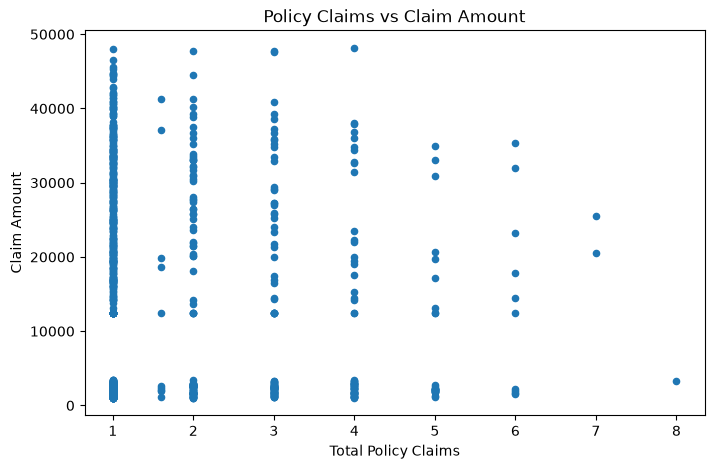

In [96]:
claim_cust.plot(
    x='total_policy_claims',
    y='claim_amount',
    kind='scatter',
    figsize=(8,5)
)

plt.title('Policy Claims vs Claim Amount')
plt.xlabel('Total Policy Claims')
plt.ylabel('Claim Amount')
plt.show()

Q20 – Statistical Test Report

Question: Is there any relationship between the total number of policy claims and the claimed amount?     <br>
H₀ (Null Hypothesis): There is no significant relationship between total policy claims and claim amount.    <br>
H₁ (Alternative Hypothesis): There is a significant relationship between total policy claims and claim amount.    <br>
Statistical Test: Pearson Correlation Test.        <br>
Significance Level: 0.05        <br>

Results:

Correlation coefficient (r) = -0.0239        <br>
p-value = 0.4297

Decision: Since p-value (0.4297) > 0.05, we fail to reject the null hypothesis.

Conclusion: There is no statistically significant relationship between the total number of policy claims and the claim amount. The correlation coefficient of -0.0239 indicates a negligible negative linear relationship. The scatter plot also shows no clear linear pattern between the two variables.